In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 13s 0us/step


In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [ ]:
print(x_train[0])

In [6]:
print(y_train[0])

[6]


In [7]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [8]:
print(y_train[0])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


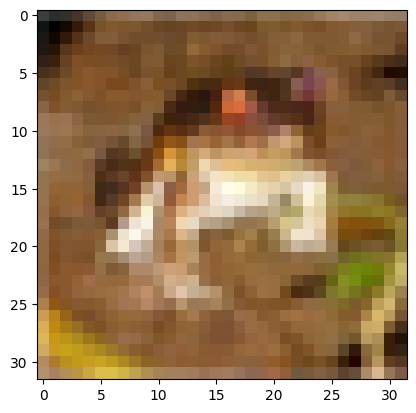

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


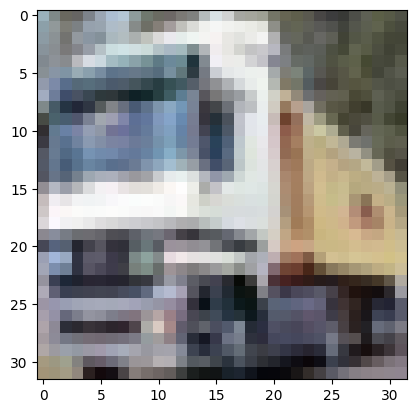

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


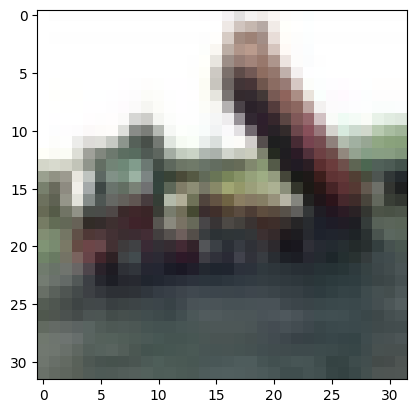

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


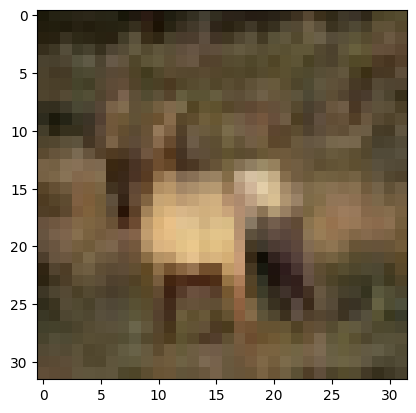

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


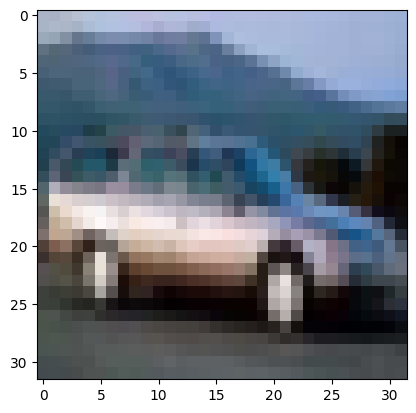

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


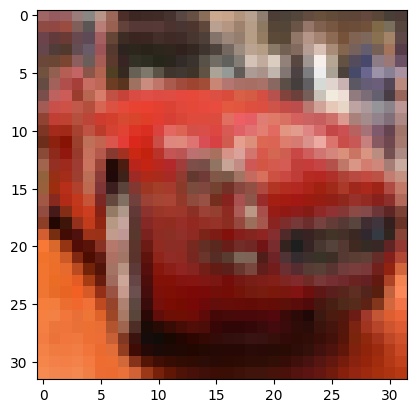

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


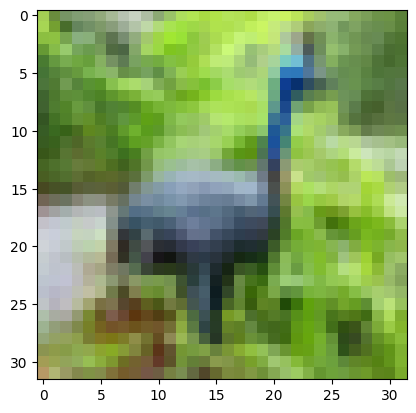

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


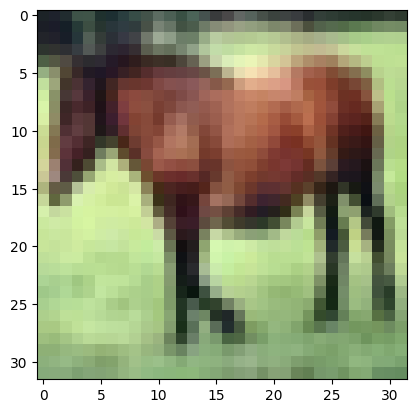

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


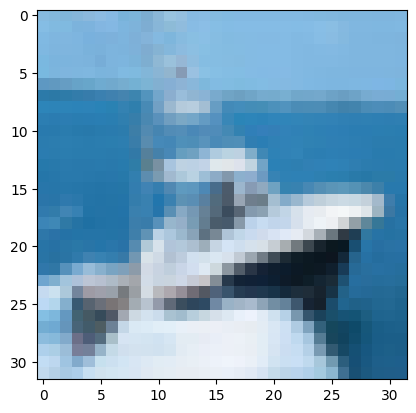

[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


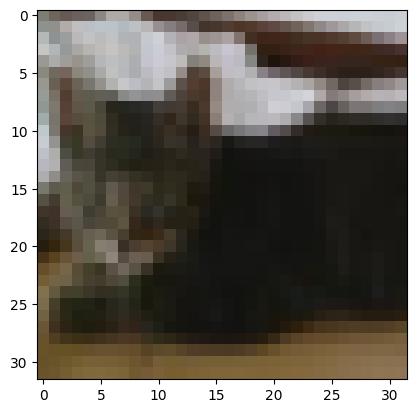

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


In [9]:
for i in range(10):
  plt.imshow(x_train[i])
  plt.show()
  print(y_train[i])

In [10]:
clasificador = keras.models.Sequential([
    keras.layers.Input(shape=[32,32,3]),
    keras.layers.Flatten(), # 32 x 32 x 3 =  3,072
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [11]:
clasificador.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 20)                61460     
                                                                 
 dense_1 (Dense)             (None, 10)                210       
                                                                 
Total params: 61670 (240.90 KB)
Trainable params: 61670 (240.90 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Keras optimizers**

https://keras.io/api/optimizers/

In [12]:
clasificador.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001), metrics=['accuracy'])

h = clasificador.fit(x_train, y_train, epochs=10, validation_split = 0.2)

Epoch 1/10
1250/1250 [==============================] - 10s 4ms/step - loss: 5.4074 - accuracy: 0.0983 - val_loss: 2.3026 - val_accuracy: 0.1017
Epoch 2/10
1250/1250 [==============================] - 4s 3ms/step - loss: 2.3028 - accuracy: 0.0987 - val_loss: 2.3026 - val_accuracy: 0.0998
Epoch 3/10
1250/1250 [==============================] - 5s 4ms/step - loss: 2.3027 - accuracy: 0.0979 - val_loss: 2.3027 - val_accuracy: 0.0998
Epoch 4/10
1250/1250 [==============================] - 4s 3ms/step - loss: 2.3028 - accuracy: 0.0974 - val_loss: 2.3027 - val_accuracy: 0.0953
Epoch 5/10
1250/1250 [==============================] - 5s 4ms/step - loss: 2.3028 - accuracy: 0.1017 - val_loss: 2.3027 - val_accuracy: 0.0978
Epoch 6/10
1250/1250 [==============================] - 5s 4ms/step - loss: 2.3028 - accuracy: 0.0981 - val_loss: 2.3026 - val_accuracy: 0.0953
Epoch 7/10
1250/1250 [==============================] - 4s 3ms/step - loss: 2.3028 - accuracy: 0.0982 - val_loss: 2.3026 - val_accuracy

In [13]:
test_loss, test_accuracy = clasificador.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 2.3098 - accuracy: 0.1000


In [14]:
clasificador.evaluate(x_test, y_test)

313/313 [==============================] - 1s 4ms/step - loss: 2.3098 - accuracy: 0.1000


[2.3098223209381104, 0.10000000149011612]

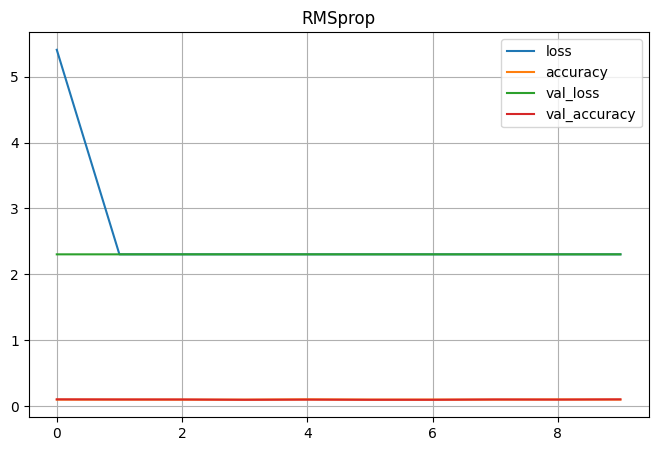

In [15]:
pd.DataFrame(h.history).plot(figsize=(8, 5))
plt.title('RMSprop')
plt.grid(True)
plt.show()